<a href="https://colab.research.google.com/github/vinaygadde2020/Student-Performance-Prediction-Using-Machine-Learning/blob/main/Student_Performance_Prediction_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction Using Machine Learning

**Domain:** Data Science & Machine Learning
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## Workflow
1. Dataset Collection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building (Linear Regression)
6. Model Evaluation
7. Student Score Prediction


## 1. Dataset Collection

We load the student performance dataset, which contains demographic, behavioral, and academic information for 200 students.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load dataset
df = pd.read_csv("/content/student_performance_dataset.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (200, 9)


,Student_ID,Gender,Age,Study_Hours,Attendance,Previous_Score,Internet_Access,Participation,Final_Score
0,STU001,Male,16,8,60,66,Yes,Low,78
1,STU002,Female,19,1,92,88,Yes,Low,69
2,STU003,Male,20,1,99,52,Yes,Low,57
3,STU004,Male,19,3,69,72,Yes,High,74
4,STU005,Male,20,6,88,73,Yes,High,83


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student_ID       200 non-null    object
 1   Gender           200 non-null    object
 2   Age              200 non-null    int64 
 3   Study_Hours      200 non-null    int64 
 4   Attendance       200 non-null    int64 
 5   Previous_Score   200 non-null    int64 
 6   Internet_Access  200 non-null    object
 7   Participation    200 non-null    object
 8   Final_Score      200 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 14.2+ KB


In [30]:
df.describe(include="all")


,Student_ID,Gender,Age,Study_Hours,Attendance,Previous_Score,Internet_Access,Participation,Final_Score
count,200,200,200.000000,200.000000,200.000000,200.000000,200,200,200.000000
unique,200,2,NaN,NaN,NaN,NaN,2,3,NaN
top,STU001,Male,NaN,NaN,NaN,NaN,Yes,Medium,NaN
freq,1,100,NaN,NaN,NaN,NaN,165,70,NaN
mean,NaN,NaN,17.875000,4.630000,80.640000,67.280000,NaN,NaN,77.525000
std,NaN,NaN,1.410433,2.284556,11.510991,16.712214,NaN,NaN,12.983537
min,NaN,NaN,16.000000,1.000000,60.000000,40.000000,NaN,NaN,42.000000
25%,NaN,NaN,16.000000,2.750000,71.000000,53.000000,NaN,NaN,69.000000
50%,NaN,NaN,18.000000,5.000000,81.000000,67.000000,NaN,NaN,78.000000
75%,NaN,NaN,19.000000,7.000000,90.250000,82.250000,NaN,NaN,87.000000


## 2. Data Cleaning & Preprocessing

Steps performed:
- Check for missing values
- Check for duplicate rows
- Check for outliers
- Encode categorical variables (Gender, Internet_Access, Participation)
- Drop irrelevant identifier columns (Student_ID)


In [31]:
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 Student_ID         0
Gender             0
Age                0
Study_Hours        0
Attendance         0
Previous_Score     0
Internet_Access    0
Participation      0
Final_Score        0
dtype: int64

Duplicate rows: 0


In [32]:
# Drop the identifier column - not useful for prediction
df_clean = df.drop(columns=["Student_ID"]).copy()

# Check unique values of categorical columns
for col in ["Gender", "Internet_Access", "Participation"]:
    print(col, ":", df_clean[col].unique())


Gender : ['Male' 'Female']
Internet_Access : ['Yes' 'No']
Participation : ['Low' 'High' 'Medium']


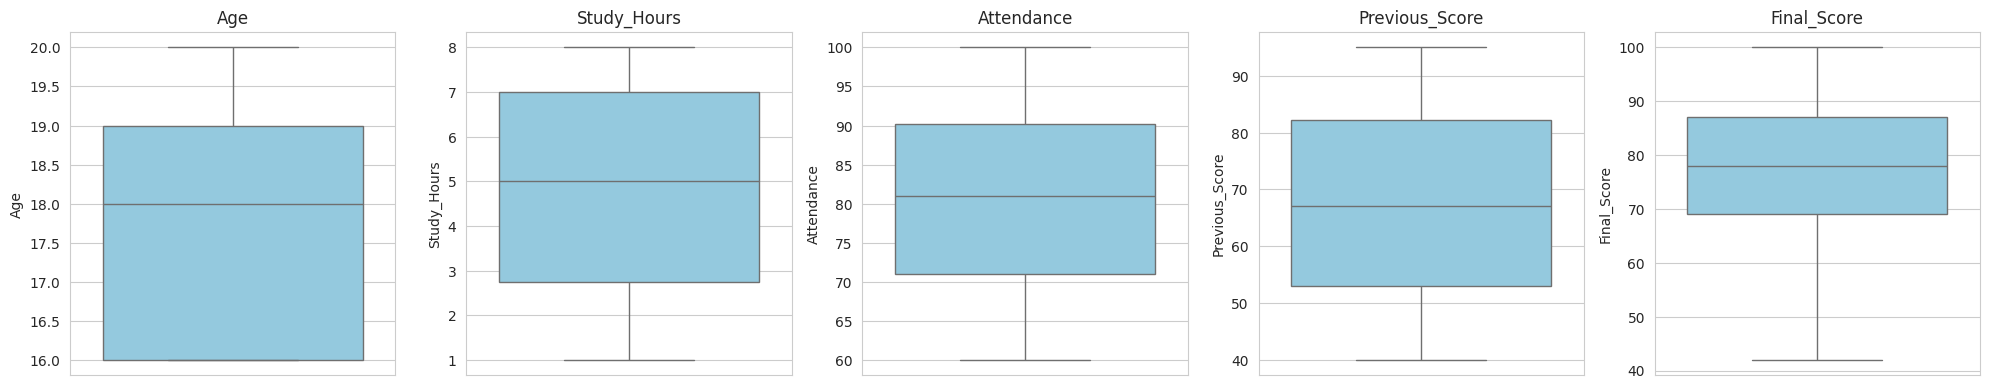

In [33]:
# Outlier check using boxplots on numeric columns
numeric_cols = ["Age", "Study_Hours", "Attendance", "Previous_Score", "Final_Score"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [34]:
# Encode categorical variables
# Gender: Male=1, Female=0
df_clean["Gender"] = df_clean["Gender"].map({"Male": 1, "Female": 0})

# Internet_Access: Yes=1, No=0
df_clean["Internet_Access"] = df_clean["Internet_Access"].map({"Yes": 1, "No": 0})

# Participation: ordinal encoding (Low < Medium < High)
participation_map = {"Low": 0, "Medium": 1, "High": 2}
df_clean["Participation"] = df_clean["Participation"].map(participation_map)

df_clean.head()


,Gender,Age,Study_Hours,Attendance,Previous_Score,Internet_Access,Participation,Final_Score
0,1,16,8,60,66,1,0,78
1,0,19,1,92,88,1,0,69
2,1,20,1,99,52,1,0,57
3,1,19,3,69,72,1,2,74
4,1,20,6,88,73,1,2,83


## 3. Exploratory Data Analysis (EDA)

We explore relationships between features and the target variable `Final_Score` to understand what drives student performance.


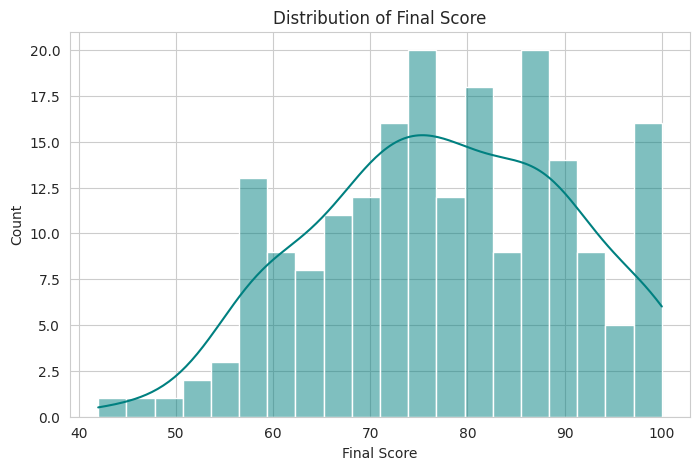

In [35]:
# Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Final_Score"], kde=True, color="teal", bins=20)
plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.show()


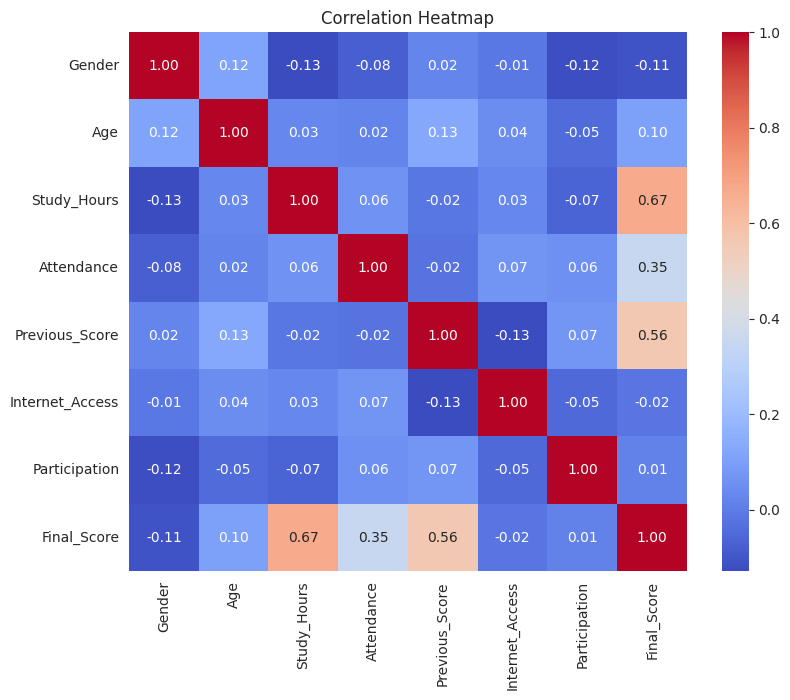

In [36]:
# Correlation heatmap
plt.figure(figsize=(9,7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [37]:
# Final Score correlation ranking
corr["Final_Score"].sort_values(ascending=False)


,Final_Score
Final_Score,1.000000
Study_Hours,0.666962
Previous_Score,0.562060
Attendance,0.349374
Age,0.102390
Participation,0.014927
Internet_Access,-0.022988
Gender,-0.110802


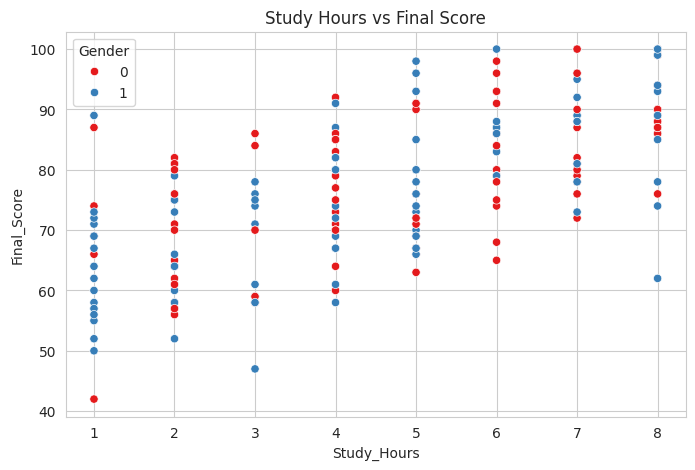

In [38]:
# Study Hours vs Final Score
plt.figure(figsize=(8,5))
sns.scatterplot(x="Study_Hours", y="Final_Score", data=df_clean, hue="Gender", palette="Set1")
plt.title("Study Hours vs Final Score")
plt.show()


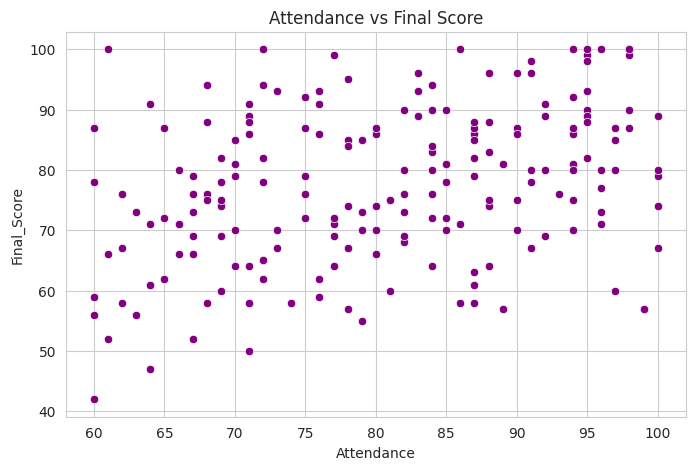

In [39]:
# Attendance vs Final Score
plt.figure(figsize=(8,5))
sns.scatterplot(x="Attendance", y="Final_Score", data=df_clean, color="purple")
plt.title("Attendance vs Final Score")
plt.show()


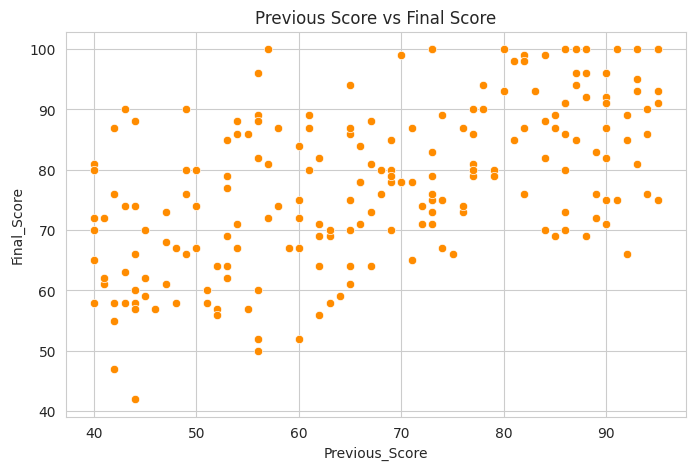

In [40]:
# Previous Score vs Final Score
plt.figure(figsize=(8,5))
sns.scatterplot(x="Previous_Score", y="Final_Score", data=df_clean, color="darkorange")
plt.title("Previous Score vs Final Score")
plt.show()


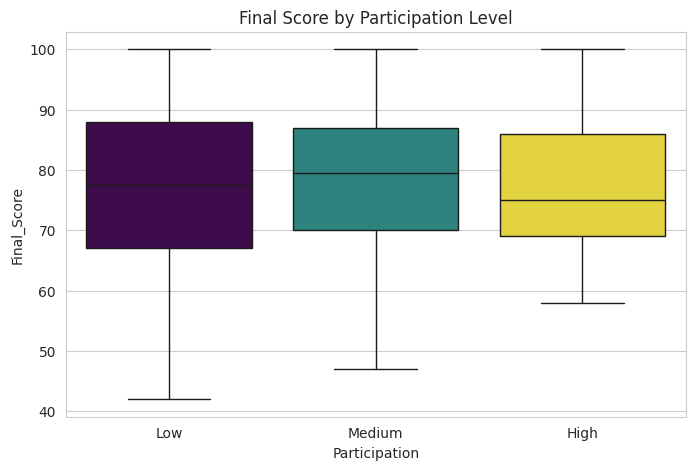

In [41]:
# Final Score by Participation level
plt.figure(figsize=(8,5))
sns.boxplot(x="Participation", y="Final_Score", data=df_clean, hue="Participation", palette="viridis", legend=False)
plt.xticks([0,1,2], ["Low", "Medium", "High"])
plt.title("Final Score by Participation Level")
plt.show()


## 4. Feature Engineering

We create a few additional features that may help the model capture patterns better:
- `Study_Attendance_Index`: combined effect of study hours and attendance
- `Score_Improvement`: difference between final and previous score (used only for analysis, not as a model input, since it leaks the target)


In [42]:
# Engineered feature: combined study & attendance index
df_clean["Study_Attendance_Index"] = (df_clean["Study_Hours"] * df_clean["Attendance"]) / 100

# For analysis only (not used as a predictor, since it directly uses the target)
df_clean["Score_Improvement"] = df_clean["Final_Score"] - df_clean["Previous_Score"]

df_clean[["Study_Hours", "Attendance", "Study_Attendance_Index", "Score_Improvement"]].head()


,Study_Hours,Attendance,Study_Attendance_Index,Score_Improvement
0,8,60,4.80,12
1,1,92,0.92,-19
2,1,99,0.99,5
3,3,69,2.07,2
4,6,88,5.28,10


In [43]:
# Define final feature set (exclude Score_Improvement - it leaks the target)
feature_cols = ["Gender", "Age", "Study_Hours", "Attendance", "Previous_Score",
                 "Internet_Access", "Participation", "Study_Attendance_Index"]

X = df_clean[feature_cols]
y = df_clean["Final_Score"]

X.head()


,Gender,Age,Study_Hours,Attendance,Previous_Score,Internet_Access,Participation,Study_Attendance_Index
0,1,16,8,60,66,1,0,4.80
1,0,19,1,92,88,1,0,0.92
2,1,20,1,99,52,1,0,0.99
3,1,19,3,69,72,1,2,2.07
4,1,20,6,88,73,1,2,5.28


## 5. Model Building (Linear Regression)

We split the data into training and testing sets, scale the features, and fit a Linear Regression model.


In [44]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (160, 8)
Testing set size: (40, 8)


In [45]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [46]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")


Model trained successfully!


In [47]:
# Inspect model coefficients
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df


,Feature,Coefficient
2,Study_Hours,8.056682
4,Previous_Score,7.668156
3,Attendance,4.303966
7,Study_Attendance_Index,0.709018
0,Gender,-0.323259
6,Participation,-0.297669
1,Age,0.076283
5,Internet_Access,0.057386


## 6. Model Evaluation

We evaluate the model using standard regression metrics: MAE, MSE, RMSE, and R² score.


In [48]:
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 3.44
Mean Squared Error (MSE): 18.32
Root Mean Squared Error (RMSE): 4.28
R² Score: 0.8891


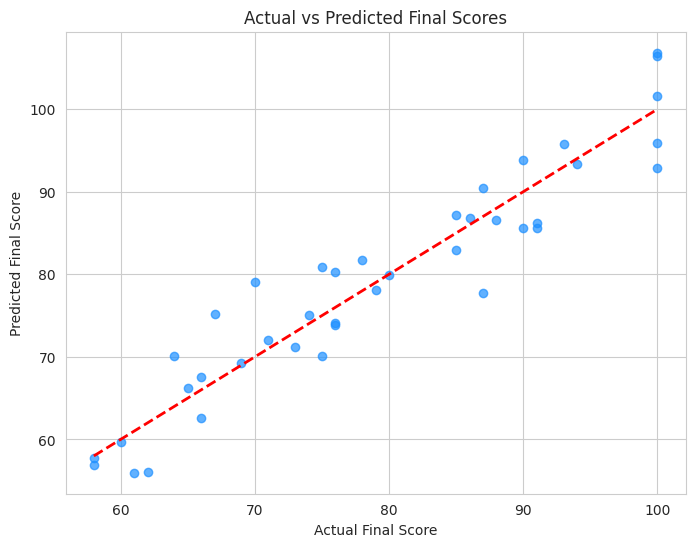

In [49]:
# Actual vs Predicted plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color="dodgerblue", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Scores")
plt.show()


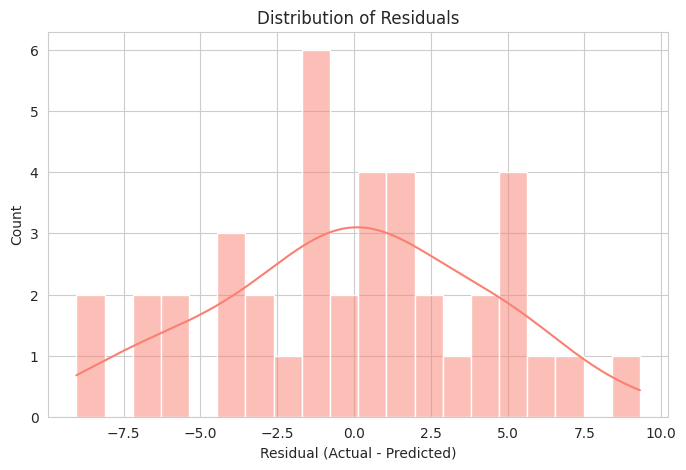

In [50]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, color="salmon", bins=20)
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()


In [51]:
# Cross-validation for a more robust performance estimate
from sklearn.model_selection import cross_val_score

X_scaled_full = scaler.fit_transform(X)
cv_scores = cross_val_score(LinearRegression(), X_scaled_full, y, cv=5, scoring="r2")

print("Cross-validation R² scores:", cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-validation R² scores: [0.84538302 0.89373783 0.87370569 0.81434176 0.86542331]
Mean CV R²: 0.8585 (+/- 0.0270)


## 7. Student Score Prediction

Finally, we use the trained model to predict the final score for new/hypothetical student data.


In [52]:
def predict_final_score(gender, age, study_hours, attendance, previous_score,
                         internet_access, participation):
    """
    gender: 'Male' or 'Female'
    internet_access: 'Yes' or 'No'
    participation: 'Low', 'Medium', or 'High'
    """
    gender_val = 1 if gender == "Male" else 0
    internet_val = 1 if internet_access == "Yes" else 0
    participation_val = {"Low": 0, "Medium": 1, "High": 2}[participation]
    study_attendance_index = (study_hours * attendance) / 100

    input_data = pd.DataFrame([{
        "Gender": gender_val,
        "Age": age,
        "Study_Hours": study_hours,
        "Attendance": attendance,
        "Previous_Score": previous_score,
        "Internet_Access": internet_val,
        "Participation": participation_val,
        "Study_Attendance_Index": study_attendance_index
    }])

    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)[0]
    return round(prediction, 2)

# Example prediction
predicted_score = predict_final_score(
    gender="Male",
    age=18,
    study_hours=6,
    attendance=85,
    previous_score=75,
    internet_access="Yes",
    participation="High"
)

print(f"Predicted Final Score: {predicted_score}")


Predicted Final Score: 86.96


In [53]:
# Try a few more example students
examples = [
    {"gender": "Female", "age": 17, "study_hours": 2, "attendance": 65, "previous_score": 50, "internet_access": "No", "participation": "Low"},
    {"gender": "Male", "age": 19, "study_hours": 8, "attendance": 95, "previous_score": 90, "internet_access": "Yes", "participation": "High"},
    {"gender": "Female", "age": 20, "study_hours": 5, "attendance": 80, "previous_score": 70, "internet_access": "Yes", "participation": "Medium"},
]

for i, ex in enumerate(examples, 1):
    score = predict_final_score(**ex)
    print(f"Student {i}: {ex} -> Predicted Final Score: {score}")


Student 1: {'gender': 'Female', 'age': 17, 'study_hours': 2, 'attendance': 65, 'previous_score': 50, 'internet_access': 'No', 'participation': 'Low'} -> Predicted Final Score: 53.64
Student 2: {'gender': 'Male', 'age': 19, 'study_hours': 8, 'attendance': 95, 'previous_score': 90, 'internet_access': 'Yes', 'participation': 'High'} -> Predicted Final Score: 105.63
Student 3: {'gender': 'Female', 'age': 20, 'study_hours': 5, 'attendance': 80, 'previous_score': 70, 'internet_access': 'Yes', 'participation': 'Medium'} -> Predicted Final Score: 79.98


## Conclusion

- Linear Regression was applied to predict student final scores based on study habits, attendance, previous performance, and other features.
- `Previous_Score`, `Study_Hours`, and `Attendance` showed the strongest positive correlation with `Final_Score`.
- The model achieved a reasonable R² score on the test set (see Model Evaluation section above), indicating that academic and behavioral features are good predictors of final performance.
- This project can be extended by trying other models (Random Forest, Gradient Boosting) and tuning hyperparameters for improved accuracy.
